Running AlievPanfilovElems: 100%|██████████| 1/1 [00:01<00:00,  1.06s/it]


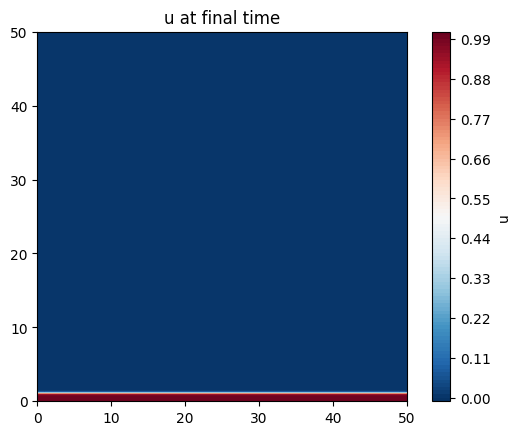

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import finitewave as fw


def build_triangular_mesh(n, m, x_range=(0, 1), y_range=(0, 1)):
    x = np.linspace(x_range[0], x_range[1], n+1)
    y = np.linspace(y_range[0], y_range[1], m+1)
    xv, yv = np.meshgrid(x, y)
    coords = np.vstack([xv.ravel(), yv.ravel(), np.zeros((n+1)*(m+1))]).T

    elems = []
    for j in range(m):
        for i in range(n):
            v0 = j * (n + 1) + i
            v1 = v0 + 1
            v2 = v0 + (n + 1)
            v3 = v2 + 1
            elems.append([v0, v1, v3])
            elems.append([v0, v3, v2])
    elems = np.array(elems)

    return coords, elems


# create a tissue of size 400x400 with cardiomycytes:
n = 400
size = 50

coords, elems = build_triangular_mesh(n, n, (0, size), (0, size))

tissue = fw.CardiacTissueElem(coords, elems)
# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoordElem(0, 1, 0, size, 0, 1))
stim_sequence.add_stim(fw.StimVoltageCoordElem(45, 1, 0, size//2, 0, size))

# create model object and set up parameters:
aliev_panfilov = fw.AlievPanfilovElems()
aliev_panfilov.dt = 0.01
aliev_panfilov.t_max = 0.01
# add the tissue and the stim parameters to the model object:
aliev_panfilov.cardiac_tissue = tissue
aliev_panfilov.stim_sequence = stim_sequence

# run the model:
aliev_panfilov.run(num_of_threads=1)

u = aliev_panfilov.u

# show the potential map at the end of calculations:
plt.figure()
plt.tricontourf(coords[:, 0], coords[:, 1], elems, u, levels=100,
                cmap="RdBu_r")
plt.colorbar(label='u')
plt.title('u at final time')
plt.gca().set_aspect('equal')
plt.show()

In [2]:
A, M = aliev_panfilov.weights

A.indptr

array([      0,       4,       9, ..., 1122392, 1122397, 1122401],
      shape=(160802,), dtype=int32)

In [ ]:
from numba import njit, prange

@njit(parallel=True)
def csr_matvec(data, indices, indptr, x, y):
    n = indptr.shape[0] - 1
    for i in prange(n):
        start, end = indptr[i], indptr[i+1]
        for j in range(start, end):
            y[i] += data[j] * x[indices[j]]
    return y


# @njit(parallel=True)
def cg_sparse(data, indices, indptr, b, atol=1e-6, maxiter=1000):
    n = len(b)
    x = np.zeros(n, dtype=np.float64)
    q = np.zeros(n, dtype=np.float64)
    r = np.zeros(n, dtype=np.float64)

    r = b - csr_matvec(data, indices, indptr, x, r)

    p = r.copy()
    rs_old = r @ r

    for iteration in range(maxiter):

        if np.linalg.norm(r) < atol:
            return x, 0
        
        rs_new = r @ r
        
        q = csr_matvec(data, indices, indptr, p, q)

        alpha = rs_old / (p @ q)
        x += alpha * p
        r -= alpha * q
        rs_new = r @ r
        p = r + (rs_new / rs_old) * p
        rs_old = rs_new

    return x, maxiter

x = u.copy()
y = np.zeros_like(u)
csr_matvec(A.data, A.indices, A.indptr, x, y)

array([0.00520834, 0.00781255, 0.00781252, ..., 0.        , 0.        ,
       0.        ], shape=(160801,))

coords: (1000, 3)
tets: (3645, 4)
(3645,) (3645, 4, 3)


c:\Users\aooke\miniconda3\envs\fw\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


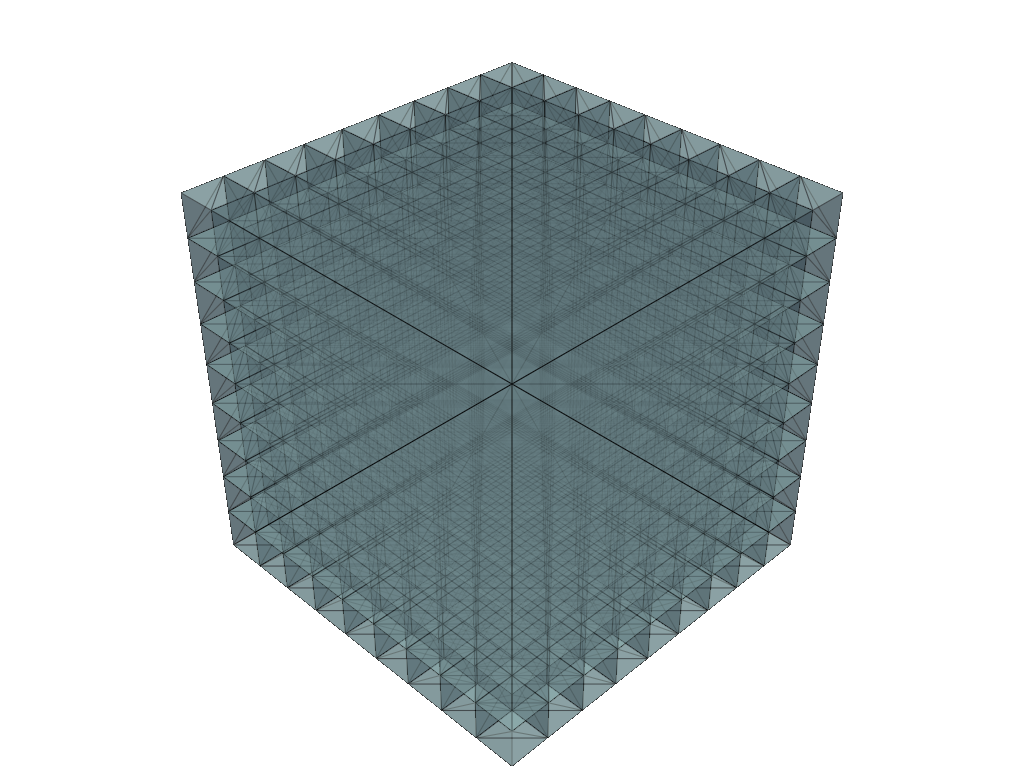

In [13]:
import numpy as np
import pyvista as pv


def generate_tet_mesh(L, H, W, nx, ny, nz):
    """
    Generate tetrahedral mesh of a box [0,L]x[0,H]x[0,W], fully vectorized.

    Parameters
    ----------
    L, H, W : float
        Dimensions of the box.
    nx, ny, nz : int
        Number of subdivisions in each direction.

    Returns
    -------
    coords : (N, 3) array
        Node coordinates.
    tets : (M, 4) array
        Tetrahedra connectivity.
    """
    # --- coordinates ---
    x = np.linspace(0, L, nx+1)
    y = np.linspace(0, H, ny+1)
    z = np.linspace(0, W, nz+1)
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    coords = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

    # --- cell indices ---
    I, J, K = np.meshgrid(
        np.arange(nx), np.arange(ny), np.arange(nz), indexing="ij"
    )
    I, J, K = I.ravel(), J.ravel(), K.ravel()

    # convert (i,j,k) to node index
    def idx(i, j, k):
        return i*(ny+1)*(nz+1) + j*(nz+1) + k

    # 8 corners of each cube
    n000 = idx(I,   J,   K  )
    n100 = idx(I+1, J,   K  )
    n010 = idx(I,   J+1, K  )
    n110 = idx(I+1, J+1, K  )
    n001 = idx(I,   J,   K+1)
    n101 = idx(I+1, J,   K+1)
    n011 = idx(I,   J+1, K+1)
    n111 = idx(I+1, J+1, K+1)

    # 5 tets per cube
    tets = np.vstack([
        np.column_stack([n000, n100, n010, n001]),
        np.column_stack([n100, n110, n010, n111]),
        np.column_stack([n100, n010, n001, n111]),
        np.column_stack([n010, n001, n011, n111]),
        np.column_stack([n100, n001, n101, n111]),
    ])

    return coords, tets


def volumes_and_grads(coords, elems):
    p0 = coords[elems[:, 0]]
    p1 = coords[elems[:, 1]]
    p2 = coords[elems[:, 2]]
    p3 = coords[elems[:, 3]]

    v0 = p1-p0
    v1 = p2-p0
    v2 = p3-p0

    cross = np.cross(v1, v2)
    dot = np.sum(v0 * cross, axis=1)
    volumes = np.abs(dot) / 6

    B = np.stack([v0, v1, v2], axis=2)
    B_inv = np.linalg.inv(B)
    grad_1_to_3 = B_inv
    grad_0 = -np.sum(B_inv, axis=1)
    grads = np.concatenate([grad_0[:, None, :], grad_1_to_3], axis=1)

    return volumes, grads

# Example usage
coords, elems = generate_tet_mesh(1.0, 1.0, 1.0, nx=9, ny=9, nz=9)
print("coords:", coords.shape)  # (N, 3)
print("tets:", elems.shape)      # (M, 4)

volumes, grads = volumes_and_grads(coords, elems)

print(volumes.shape, grads.shape)

cells = np.hstack([np.full((elems.shape[0], 1), 4), elems]).ravel()
celltypes = np.full(elems.shape[0], pv.CellType.TETRA, dtype=np.uint8)

grid = pv.UnstructuredGrid(cells, celltypes, coords)

# --- Visualization ---
plotter = pv.Plotter()
plotter.add_mesh(grid, show_edges=True, color="lightblue", opacity=0.6)
plotter.show()


In [ ]:
import numpy as np


coords = np.arange(15).reshape((5, 3))

elems = np.array([[0, 1, 2, 3], [2, 3, 4, 0]])

p0 = coords[elems[:, 0]]
p1 = coords[elems[:, 1]]
p2 = coords[elems[:, 2]]
p3 = coords[elems[:, 3]]

v0 = p1-p0
v1 = p2-p0
v2 = p3-p0

print(v0.shape)
print(v1.shape)

np.cross(v0, v1)[:, ]



(2, 3)
(2, 3)


(2, 3)

In [9]:
q = np.arange(u.shape[0]).astype(np.float64)
p = q.copy()
x = np.zeros_like(q)
y = np.zeros_like(q)

%timeit A @ q
%timeit csr_matvec(A.data, A.indices, A.indptr, x, y)
%timeit M @ q
%timeit csr_matvec(M.data, M.indices, M.indptr, x, y)
%timeit p @ q

2.66 ms ± 217 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.64 ms ± 112 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.51 ms ± 162 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.69 ms ± 22.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
89.6 μs ± 933 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [11]:
%timeit M.dot(q)
%timeit M @ q

2.67 ms ± 53.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.83 ms ± 64.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
import numpy as np

x = np.random.random((256, 256, 256))
y = np.random.random((256, 256, 256))

if x.ndim == 2:
    slices = (slice(100, 110), slice(100, 110))
elif x.ndim == 3:
    slices = (slice(100, 110), slice(100, 110), slice(100, 110))

%timeit x[slices]

38.9 ms ± 467 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
